# Monte Carlo Simulation of Liver Disease Progression and Treatment Outcomes

## Project objective

This notebook uses a **synthetic cohort of 10,000 hypothetical patients** to simulate chronic liver disease progression and treatment outcomes over a 10-year horizon.

The project combines:
- exploratory data analysis,
- patient-level logistic risk scoring,
- probabilistic disease-state transitions, and
- repeated Monte Carlo simulation to quantify simulation uncertainty.

> **Important:** The patient data, coefficients, transition assumptions, and treatment effects are synthetic. They are constructed for statistical and data-science demonstration only. They are **not clinical evidence**, are not estimated from real patient records, and should not be used for clinical decision-making.

### Project history

- **Phase 1:** synthetic cohort generation.
- **Phase 2:** fixed, group-level transition probabilities.
- **Phase 2.1:** recalibration after the first fixed-transition run produced an implausible mortality result.
- **Phase 3:** individualized patient-level transition-risk model.
- **Phase 3 extension:** repeated Monte Carlo runs and sensitivity analysis to assess how stable the simulated results are under repeated random sampling.

## 1. Setup and reproducibility

All figures are rendered inline in the notebook. The workflow intentionally separates **model development and visual inspection** from the later task of exporting project outputs. Sensitivity scenarios use common random seeds to isolate changes in the assumed treatment effect from ordinary Monte Carlo sampling variation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_SEED = 20260903
rng = np.random.default_rng(RANDOM_SEED)
INPUT_PATH = "synthetic_liver_disease_patients.csv"
N_YEARS = 10

print(f"Random seed: {RANDOM_SEED}")
print(f"Simulation horizon: {N_YEARS} years")

Random seed: 20260903
Simulation horizon: 10 years


## 2. Load and validate the synthetic cohort

In [2]:
patients = pd.read_csv(INPUT_PATH)
print(f"Rows: {len(patients):,}")
print(f"Columns: {patients.shape[1]}")
patients.head(10)

Rows: 10,000
Columns: 12


,Patient_ID,Age,Sex,BMI,Diabetes,Smoking,Alcohol_Exposure,Initial_Stage,Biomarker_Level,Comorbidity_Count,Treatment,Treatment_Adherence
0,P00001,24,Female,34.100,No,No,No,Moderate,62.500,0,No Treatment,0.000
1,P00002,70,Male,35.800,Yes,No,Yes,Early,61.300,1,Treatment,89.500
2,P00003,62,Male,28.700,No,No,No,Moderate,70.400,0,Treatment,74.900
3,P00004,47,Female,20.900,No,Yes,Yes,Early,43.200,1,Treatment,67.900
4,P00005,47,Female,35.900,No,No,No,Moderate,48.900,0,No Treatment,0.000
5,P00006,76,Female,21.900,No,No,Yes,Early,42.500,1,No Treatment,0.000
6,P00007,23,Male,28.700,No,No,No,Early,33.900,0,No Treatment,0.000
7,P00008,65,Male,25.700,No,No,No,Early,69.300,2,No Treatment,0.000
8,P00009,31,Male,24.800,No,No,No,Severe,60.600,0,Treatment,88.400
9,P00010,24,Female,30.800,No,Yes,Yes,Moderate,60.400,0,No Treatment,0.000


In [3]:
quality_check = pd.DataFrame({
    "Metric": [
        "Rows", "Columns", "Duplicate Patient IDs", "Missing values",
        "Minimum age", "Maximum age", "Minimum BMI", "Maximum BMI",
    ],
    "Value": [
        len(patients), patients.shape[1],
        patients["Patient_ID"].duplicated().sum(),
        patients.isna().sum().sum(),
        patients["Age"].min(), patients["Age"].max(),
        patients["BMI"].min(), patients["BMI"].max(),
    ],
})
quality_check

,Metric,Value
0,Rows,"10,000.000"
1,Columns,12.000
2,Duplicate Patient IDs,0.000
3,Missing values,0.000
4,Minimum age,18.000
5,Maximum age,85.000
6,Minimum BMI,17.000
7,Maximum BMI,44.800


### Interpretation

The cohort contains 10,000 patient records and 12 variables. The quality checks show no duplicate patient identifiers and no missing values in the supplied synthetic dataset. The observed age and BMI ranges are also reported so that the simulation is transparent about the population being modeled.

## 3. Explore the synthetic cohort

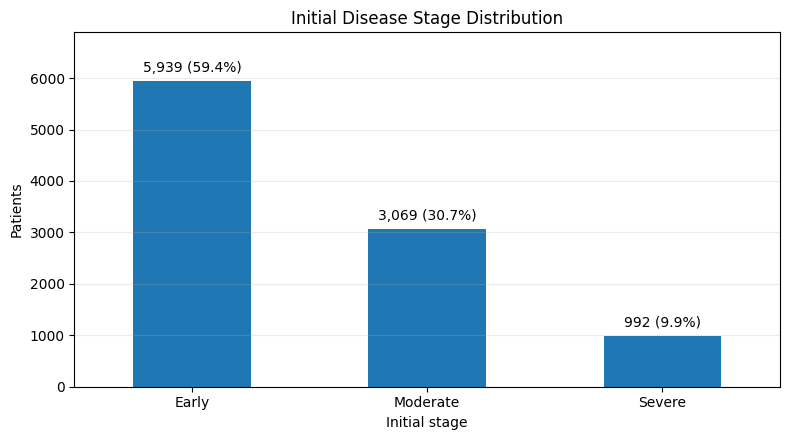

In [4]:
stage_order = ["Early", "Moderate", "Severe"]
stage_counts = patients["Initial_Stage"].value_counts().reindex(stage_order)
treatment_counts = patients["Treatment"].value_counts().reindex(["No Treatment", "Treatment"])
stage_pct = stage_counts / stage_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
stage_counts.plot(kind="bar", ax=ax)
ax.set_title("Initial Disease Stage Distribution")
ax.set_xlabel("Initial stage")
ax.set_ylabel("Patients")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
for i, (count, pct) in enumerate(zip(stage_counts, stage_pct)):
    ax.text(i, count + stage_counts.max() * 0.02, f"{count:,} ({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, stage_counts.max() * 1.16)
plt.tight_layout()
plt.show()


### Interpretation: initial disease stage

Most simulated patients begin in the **Early** stage, followed by **Moderate**, while **Severe** disease represents the smallest starting group. This starting composition matters because the population-level 10-year outcomes depend partly on where patients begin in the disease-state process.

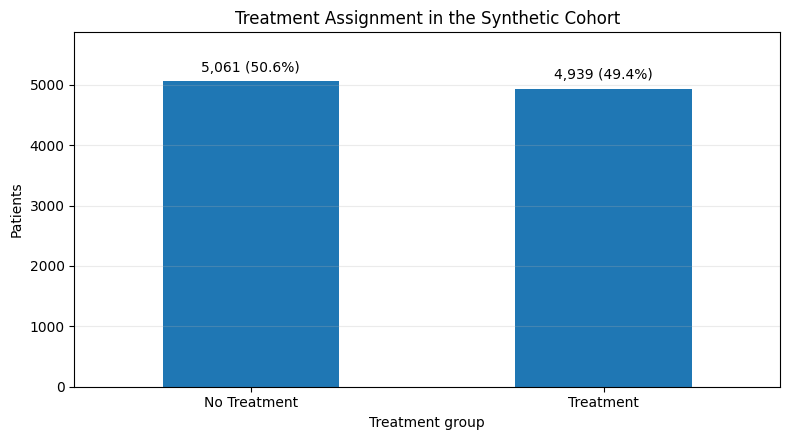

,Metric,Value
0,Mean age,51.252
1,Mean BMI,27.204
2,Diabetes,0.216
3,Smoking,0.191
4,Alcohol exposure,0.226
5,Treatment,0.494


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
treatment_counts.plot(kind="bar", ax=ax)
ax.set_title("Treatment Assignment in the Synthetic Cohort")
ax.set_xlabel("Treatment group")
ax.set_ylabel("Patients")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
treatment_pct = treatment_counts / treatment_counts.sum() * 100
for i, (count, pct) in enumerate(zip(treatment_counts, treatment_pct)):
    ax.text(i, count + treatment_counts.max() * 0.02, f"{count:,} ({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, treatment_counts.max() * 1.16)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "Metric": ["Mean age", "Mean BMI", "Diabetes", "Smoking", "Alcohol exposure", "Treatment"],
    "Value": [
        patients["Age"].mean(), patients["BMI"].mean(),
        (patients["Diabetes"] == "Yes").mean(), (patients["Smoking"] == "Yes").mean(),
        (patients["Alcohol_Exposure"] == "Yes").mean(), (patients["Treatment"] == "Treatment").mean(),
    ],
})
summary


### Interpretation: treatment assignment and baseline profile

Treatment is assigned to roughly half of the synthetic cohort, while the remaining patients form the no-treatment group. The baseline variables provide heterogeneity for the patient-level risk model, but they should be interpreted as **simulation inputs rather than measured clinical predictors**. The treatment split is also synthetic and should not be interpreted as clinical eligibility, physician choice, or random treatment assignment.


## 4. Patient-level transition-risk model

The model below is deliberately described as a **synthetic patient-level risk model**, not as a fitted multinomial logistic regression. No clinical outcome data were used to estimate these coefficients.

For each patient and current disease stage, two latent log-odds scores are calculated:

- probability of progressing to the next disease stage,
- probability of death.

The two scores are converted to mutually exclusive transition probabilities. Treatment effects are scaled by the synthetic adherence variable. The model therefore creates patient-level heterogeneity while preserving the state-transition structure used in the calibrated simulation.


In [6]:
STATES = ["Early", "Moderate", "Severe", "Death"]
STATE_IDX = {s: i for i, s in enumerate(STATES)}

REF_AGE, REF_BMI, REF_BIOMARKER = 51, 27, 55

# Synthetic reference intercepts based on the calibrated Phase 2.1 transition assumptions.
INTERCEPT_PROGRESS = {"Early": -1.970, "Moderate": -1.322}
INTERCEPT_DEATH = {"Early": -3.761, "Moderate": -2.708, "Severe": -1.992}

# Synthetic covariate coefficients. These are assumptions, not fitted clinical estimates.
COEF_PROGRESS = dict(age=0.15, bmi=0.10, diabetes=0.30, smoking=0.15,
                      alcohol=0.35, biomarker=0.45, comorbidity=0.20)
COEF_DEATH = dict(age=0.25, bmi=0.10, diabetes=0.35, smoking=0.20,
                  alcohol=0.30, biomarker=0.55, comorbidity=0.25)

# Synthetic treatment effects at full adherence; effect varies by current stage.
TX_BETA_PROGRESS = {"Early": 0.916, "Moderate": 0.470}
TX_BETA_DEATH = {"Early": 1.386, "Moderate": 0.799, "Severe": 0.470}

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -50, 50)))

def build_risk_components(df, treatment_effect_multiplier=1.0):
    age = df["Age"].to_numpy(float)
    bmi = df["BMI"].to_numpy(float)
    diabetes = (df["Diabetes"] == "Yes").to_numpy(float)
    smoking = (df["Smoking"] == "Yes").to_numpy(float)
    alcohol = (df["Alcohol_Exposure"] == "Yes").to_numpy(float)
    biomarker = df["Biomarker_Level"].to_numpy(float)
    comorbidity = df["Comorbidity_Count"].to_numpy(float)
    treated = (df["Treatment"] == "Treatment").to_numpy(float)
    adherence = df["Treatment_Adherence"].to_numpy(float) / 100.0
    tx_fraction = treated * adherence

    progress_score = (
        COEF_PROGRESS["age"] * (age - REF_AGE) / 10
        + COEF_PROGRESS["bmi"] * (bmi - REF_BMI) / 5
        + COEF_PROGRESS["diabetes"] * diabetes
        + COEF_PROGRESS["smoking"] * smoking
        + COEF_PROGRESS["alcohol"] * alcohol
        + COEF_PROGRESS["biomarker"] * (biomarker - REF_BIOMARKER) / 10
        + COEF_PROGRESS["comorbidity"] * comorbidity
    )
    death_score = (
        COEF_DEATH["age"] * (age - REF_AGE) / 10
        + COEF_DEATH["bmi"] * (bmi - REF_BMI) / 5
        + COEF_DEATH["diabetes"] * diabetes
        + COEF_DEATH["smoking"] * smoking
        + COEF_DEATH["alcohol"] * alcohol
        + COEF_DEATH["biomarker"] * (biomarker - REF_BIOMARKER) / 10
        + COEF_DEATH["comorbidity"] * comorbidity
    )
    return progress_score, death_score, tx_fraction

cov_score_progress, cov_score_death, tx_fraction = build_risk_components(patients)

pd.DataFrame({
    "Progression score": cov_score_progress,
    "Death score": cov_score_death
}).describe().round(3)

,Progression score,Death score
count,"10,000.000","10,000.000"
mean,0.551,0.652
std,1.034,1.345
min,-2.525,-3.299
25%,-0.194,-0.324
50%,0.522,0.620
75%,1.264,1.586
max,5.561,6.887


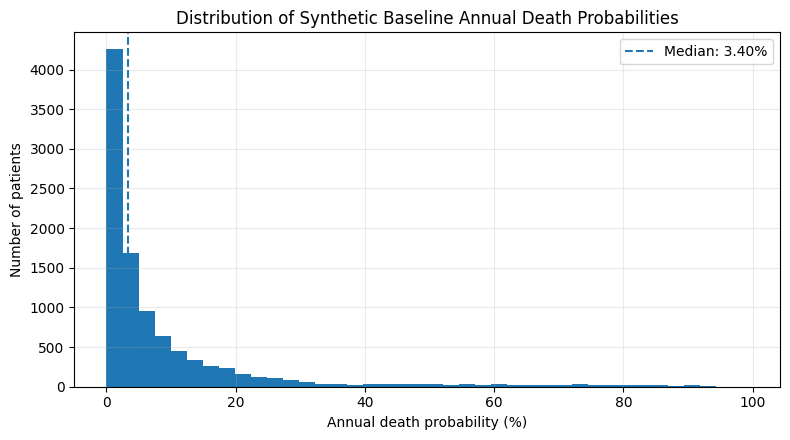

In [7]:
# Convert the baseline death score into an interpretable annual death probability.
# At this point in the notebook the transition function has not yet been defined,
# so the same probability construction is reproduced directly for the initial states.
initial_state = patients["Initial_Stage"].map(STATE_IDX).to_numpy()
p_death_base = np.zeros(len(patients))
for state_name in ["Early", "Moderate", "Severe"]:
    mask = initial_state == STATE_IDX[state_name]
    eta_death = (
        INTERCEPT_DEATH[state_name]
        + cov_score_death[mask]
        - TX_BETA_DEATH[state_name] * tx_fraction[mask]
    )
    exp_d = np.exp(np.clip(eta_death, -50, 50))
    if state_name in INTERCEPT_PROGRESS:
        eta_progress = (
            INTERCEPT_PROGRESS[state_name]
            + cov_score_progress[mask]
            - TX_BETA_PROGRESS[state_name] * tx_fraction[mask]
        )
        exp_p = np.exp(np.clip(eta_progress, -50, 50))
        p_death_base[mask] = exp_d / (1 + exp_p + exp_d)
    else:
        p_death_base[mask] = exp_d / (1 + exp_d)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(p_death_base * 100, bins=40)
median_death_prob = np.median(p_death_base * 100)
ax.axvline(median_death_prob, linestyle="--", label=f"Median: {median_death_prob:.2f}%")
ax.set_title("Distribution of Synthetic Baseline Annual Death Probabilities")
ax.set_xlabel("Annual death probability (%)")
ax.set_ylabel("Number of patients")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Interpretation: patient-level heterogeneity

The distribution shows that patients receive different **synthetic annual death probabilities at baseline**, rather than one identical risk value. The spread is created by differences in the synthetic patient characteristics and treatment/adherence inputs. This is the main difference from the earlier fixed-transition model: two patients who share the same disease stage can still have different simulated transition probabilities.

Because these probabilities are generated from assumed coefficients rather than fitted to clinical outcomes, they are useful for demonstrating model behavior, not for estimating real-world patient risk.


## 5. Convert risk scores into transition probabilities

For Early and Moderate disease, the model considers three mutually exclusive outcomes in the next yearly step: **stay in the current state, progress, or die**. For Severe disease, the next step is either **remain Severe or die**. Death is absorbing, meaning a patient who reaches Death remains there.

In [8]:
def transition_probabilities(df, current_state, treatment_effect_multiplier=1.0):
    progress_score, death_score, tx_fraction = build_risk_components(
        df, treatment_effect_multiplier=treatment_effect_multiplier
    )
    n = len(df)
    p_stay = np.ones(n)
    p_progress = np.zeros(n)
    p_death = np.zeros(n)

    for state_name in ["Early", "Moderate", "Severe"]:
        mask = current_state == STATE_IDX[state_name]
        if not mask.any():
            continue

        eta_death = (
            INTERCEPT_DEATH[state_name]
            + death_score[mask]
            - treatment_effect_multiplier * TX_BETA_DEATH[state_name] * tx_fraction[mask]
        )

        if state_name in INTERCEPT_PROGRESS:
            eta_progress = (
                INTERCEPT_PROGRESS[state_name]
                + progress_score[mask]
                - treatment_effect_multiplier * TX_BETA_PROGRESS[state_name] * tx_fraction[mask]
            )
            exp_p = np.exp(np.clip(eta_progress, -50, 50))
            exp_d = np.exp(np.clip(eta_death, -50, 50))
            denom = 1 + exp_p + exp_d
            p_progress[mask] = exp_p / denom
            p_death[mask] = exp_d / denom
            p_stay[mask] = 1 / denom
        else:
            exp_d = np.exp(np.clip(eta_death, -50, 50))
            denom = 1 + exp_d
            p_death[mask] = exp_d / denom
            p_stay[mask] = 1 / denom

    return p_stay, p_progress, p_death

# Validate probability construction at baseline.
initial_state = patients["Initial_Stage"].map(STATE_IDX).to_numpy()
p_stay, p_progress, p_death = transition_probabilities(patients, initial_state)

prob_check = pd.DataFrame({
    "stay": p_stay,
    "progress": p_progress,
    "death": p_death,
    "sum": p_stay + p_progress + p_death
})
print(f"Minimum probability sum: {prob_check['sum'].min():.12f}")
print(f"Maximum probability sum: {prob_check['sum'].max():.12f}")
print(f"All probabilities valid: {((prob_check.iloc[:, :3] >= 0) & (prob_check.iloc[:, :3] <= 1)).all().all()}")
prob_check.head()

Minimum probability sum: 1.000000000000
Maximum probability sum: 1.000000000000
All probabilities valid: True


,stay,progress,death,sum
0,0.743,0.213,0.044,1.000
1,0.742,0.225,0.033,1.000
2,0.635,0.291,0.074,1.000
3,0.924,0.068,0.007,1.000
4,0.782,0.178,0.040,1.000


### Interpretation: probability validation

The transition probabilities are constrained to the interval [0, 1] and sum to 1 for every patient. This check is essential because the Monte Carlo simulation samples one and only one next state at each yearly step.

## 6. One 10-year Monte Carlo simulation

A single run follows all 10,000 synthetic patients for 10 yearly transitions. At each year, a random draw determines the next disease state using that patient's transition probabilities.

In [9]:
def simulate_cohort(df, n_years=10, seed=20260903, treatment_effect_multiplier=1.0, keep_trajectories=True):
    local_rng = np.random.default_rng(seed)
    current_state = df["Initial_Stage"].map(STATE_IDX).to_numpy()
    state_names_arr = np.array(STATES)
    year_frames = []

    # These patient-level components do not change across years, so calculate them once.
    progress_score, death_score, tx_fraction = build_risk_components(
        df, treatment_effect_multiplier=treatment_effect_multiplier
    )

    def snapshot(year, state_arr):
        if keep_trajectories:
            year_frames.append(pd.DataFrame({
                "Patient_ID": df["Patient_ID"].to_numpy(),
                "Year": year,
                "Treatment": df["Treatment"].to_numpy(),
                "Disease_Stage": state_names_arr[state_arr],
            }))

    snapshot(0, current_state)

    for year in range(1, n_years + 1):
        n = len(df)
        p_stay = np.ones(n)
        p_progress = np.zeros(n)
        p_death = np.zeros(n)

        for state_name in ["Early", "Moderate", "Severe"]:
            mask = current_state == STATE_IDX[state_name]
            if not mask.any():
                continue

            eta_death = (
                INTERCEPT_DEATH[state_name]
                + death_score[mask]
                - treatment_effect_multiplier * TX_BETA_DEATH[state_name] * tx_fraction[mask]
            )

            if state_name in INTERCEPT_PROGRESS:
                eta_progress = (
                    INTERCEPT_PROGRESS[state_name]
                    + progress_score[mask]
                    - treatment_effect_multiplier * TX_BETA_PROGRESS[state_name] * tx_fraction[mask]
                )
                exp_p = np.exp(np.clip(eta_progress, -50, 50))
                exp_d = np.exp(np.clip(eta_death, -50, 50))
                denom = 1 + exp_p + exp_d
                p_progress[mask] = exp_p / denom
                p_death[mask] = exp_d / denom
                p_stay[mask] = 1 / denom
            else:
                exp_d = np.exp(np.clip(eta_death, -50, 50))
                denom = 1 + exp_d
                p_death[mask] = exp_d / denom
                p_stay[mask] = 1 / denom

        u = local_rng.random(n)
        new_state = current_state.copy()
        alive = current_state != STATE_IDX["Death"]
        new_state[alive & (u < p_death)] = STATE_IDX["Death"]
        progress_mask = alive & (u >= p_death) & (u < p_death + p_progress)
        new_state[progress_mask] = current_state[progress_mask] + 1
        new_state[current_state == STATE_IDX["Death"]] = STATE_IDX["Death"]
        current_state = new_state
        snapshot(year, current_state)

    if keep_trajectories:
        return pd.concat(year_frames, ignore_index=True)
    return current_state

trajectories = simulate_cohort(patients, N_YEARS, seed=RANDOM_SEED, keep_trajectories=True)
print(f"Trajectory rows: {len(trajectories):,}")
trajectories.head(10)


Trajectory rows: 110,000


,Patient_ID,Year,Treatment,Disease_Stage
0,P00001,0,No Treatment,Moderate
1,P00002,0,Treatment,Early
2,P00003,0,Treatment,Moderate
3,P00004,0,Treatment,Early
4,P00005,0,No Treatment,Moderate
5,P00006,0,No Treatment,Early
6,P00007,0,No Treatment,Early
7,P00008,0,No Treatment,Early
8,P00009,0,Treatment,Severe
9,P00010,0,No Treatment,Moderate


## 7. Disease-state distribution over time

In [10]:
yearly = (
    trajectories.groupby(["Year", "Treatment"])
    .agg(
        Patients=("Patient_ID", "nunique"),
        Early=("Disease_Stage", lambda x: (x == "Early").sum()),
        Moderate=("Disease_Stage", lambda x: (x == "Moderate").sum()),
        Severe=("Disease_Stage", lambda x: (x == "Severe").sum()),
        Death=("Disease_Stage", lambda x: (x == "Death").sum()),
    )
    .reset_index()
)
yearly["Alive"] = yearly["Early"] + yearly["Moderate"] + yearly["Severe"]
yearly["Mortality_Rate"] = yearly["Death"] / yearly["Patients"]
yearly["Survival_Rate"] = yearly["Alive"] / yearly["Patients"]
yearly["Severe_Rate"] = yearly["Severe"] / yearly["Patients"]

yearly.head()

,Year,Treatment,Patients,Early,Moderate,Severe,Death,Alive,Mortality_Rate,Survival_Rate,Severe_Rate
0,0,No Treatment,5061,2975,1576,510,0,5061,0.000,1.000,0.101
1,0,Treatment,4939,2964,1493,482,0,4939,0.000,1.000,0.098
2,1,No Treatment,5061,2329,1395,796,541,4520,0.107,0.893,0.157
3,1,Treatment,4939,2655,1205,719,360,4579,0.073,0.927,0.146
4,2,No Treatment,5061,1910,1132,906,1113,3948,0.220,0.780,0.179


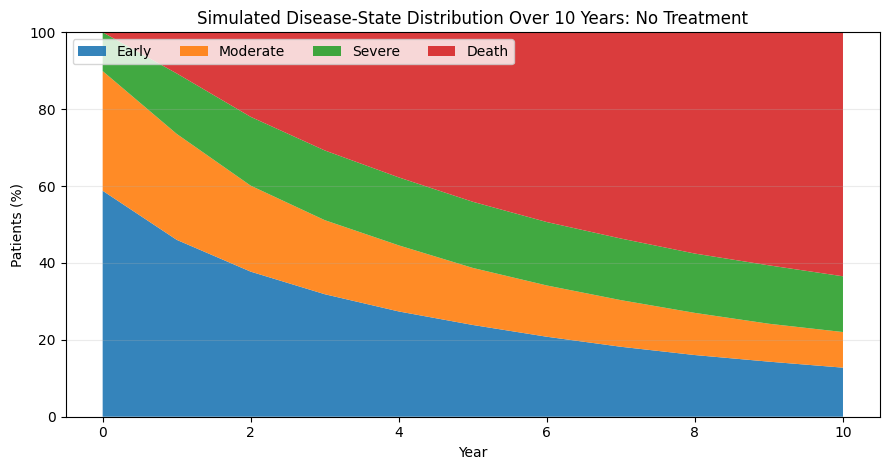

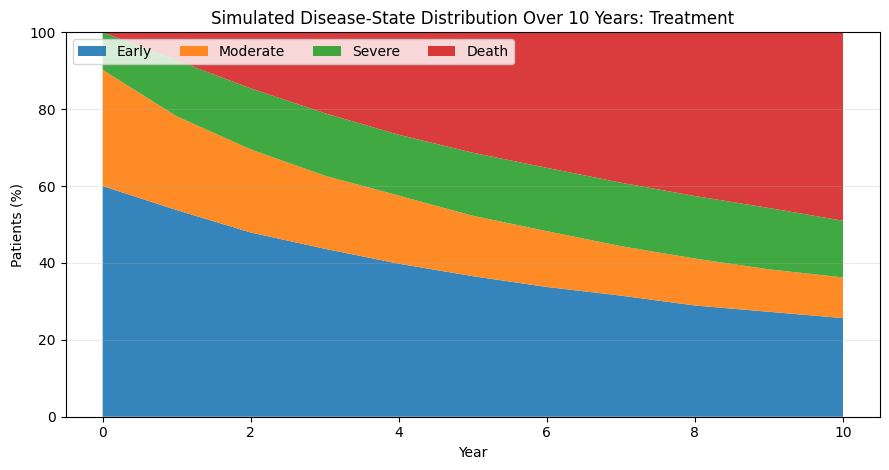

In [11]:
state_cols = ["Early", "Moderate", "Severe", "Death"]

for group in ["No Treatment", "Treatment"]:
    s = yearly[yearly["Treatment"] == group].copy()
    for col in state_cols:
        s[f"{col}_Pct"] = s[col] / s["Patients"] * 100

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.stackplot(s["Year"], *[s[f"{col}_Pct"] for col in state_cols], labels=state_cols, alpha=0.9)
    ax.set_title(f"Simulated Disease-State Distribution Over 10 Years: {group}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Patients (%)")
    ax.set_ylim(0, 100)
    ax.legend(loc="upper left", ncol=4)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


### Interpretation: disease-state trajectories

The 100% stacked area charts show how the composition of each treatment group changes over the 10-year simulation. As time progresses, the **Death** segment expands while the proportions remaining in Early, Moderate, and Severe states change. The treatment scenario retains a larger share of patients in living states, particularly the Early state, under the assumed synthetic treatment effect.

These trajectories describe the behavior of the simulation under its stated assumptions, not the natural history of real liver disease.


## 8. Year-10 treatment comparison

In [12]:
final = yearly[yearly["Year"] == N_YEARS].copy()
no_tx = final[final["Treatment"] == "No Treatment"].iloc[0]
tx = final[final["Treatment"] == "Treatment"].iloc[0]

risk_no_tx = no_tx["Mortality_Rate"]
risk_tx = tx["Mortality_Rate"]
arr = risk_no_tx - risk_tx
rr = risk_tx / risk_no_tx
nnt = 1 / arr if arr > 0 else np.nan

comparison = pd.DataFrame({
    "Outcome": ["Mortality", "Survival", "Severe disease", "Early disease", "Moderate disease"],
    "No Treatment": [risk_no_tx, no_tx["Survival_Rate"], no_tx["Severe_Rate"], no_tx["Early"] / no_tx["Patients"], no_tx["Moderate"] / no_tx["Patients"]],
    "Treatment": [risk_tx, tx["Survival_Rate"], tx["Severe_Rate"], tx["Early"] / tx["Patients"], tx["Moderate"] / tx["Patients"]],
})

display_comparison = comparison.copy()
for col in ["No Treatment", "Treatment"]:
    display_comparison[col] = display_comparison[col].map(lambda x: f"{x*100:.2f}%")
display_comparison

,Outcome,No Treatment,Treatment
0,Mortality,63.47%,49.02%
1,Survival,36.53%,50.98%
2,Severe disease,14.50%,14.74%
3,Early disease,12.76%,25.65%
4,Moderate disease,9.27%,10.59%


In [13]:
effect_measures = pd.DataFrame({
    "Measure": ["Absolute Risk Reduction", "Relative Risk", "Simulation-based NNT"],
    "Value": [f"{arr*100:.2f} percentage points", f"{rr:.3f}", f"{nnt:.1f}"]
})
effect_measures

,Measure,Value
0,Absolute Risk Reduction,14.45 percentage points
1,Relative Risk,0.772
2,Simulation-based NNT,6.9


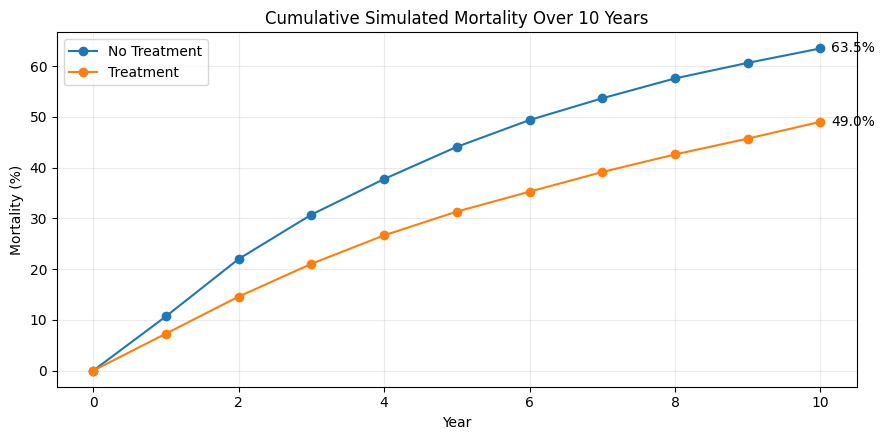

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
no_tx_series = yearly[yearly["Treatment"] == "No Treatment"].sort_values("Year")
tx_series = yearly[yearly["Treatment"] == "Treatment"].sort_values("Year")
ax.plot(no_tx_series["Year"], no_tx_series["Mortality_Rate"] * 100, marker="o", label="No Treatment")
ax.plot(tx_series["Year"], tx_series["Mortality_Rate"] * 100, marker="o", label="Treatment")

# Label the Year-10 endpoints directly so the final comparison can be read without estimating from the axis.
ax.annotate(f"{no_tx_series.iloc[-1]['Mortality_Rate']*100:.1f}%", 
            (no_tx_series.iloc[-1]["Year"], no_tx_series.iloc[-1]["Mortality_Rate"] * 100),
            xytext=(8, 0), textcoords="offset points", va="center")
ax.annotate(f"{tx_series.iloc[-1]['Mortality_Rate']*100:.1f}%", 
            (tx_series.iloc[-1]["Year"], tx_series.iloc[-1]["Mortality_Rate"] * 100),
            xytext=(8, 0), textcoords="offset points", va="center")

ax.set_title("Cumulative Simulated Mortality Over 10 Years")
ax.set_xlabel("Year")
ax.set_ylabel("Mortality (%)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Interpretation: treatment comparison

In this single simulation, treatment produces lower simulated 10-year mortality than no treatment. The **absolute risk reduction**, **relative risk**, and **simulation-based NNT** summarize the difference between the two synthetic scenarios.

These quantities should be read as **simulation outputs**, not clinical treatment-effect estimates. Because treatment assignment, adherence, coefficients, and transitions were synthetically specified, the results do not establish a causal treatment effect in real patients.

## 9. Repeated Monte Carlo simulation: quantify simulation uncertainty

A single Monte Carlo run contains random sampling variation. To examine that variation, we repeat the full 10-year cohort simulation many times.

The intervals below are **simulation intervals** based on repeated runs. They are not confidence intervals for a real-world population.

In [15]:
N_REPS = 300
rep_rng = np.random.default_rng(RANDOM_SEED + 1)

# Use independent seeds so each replication represents a new Monte Carlo realization.
rep_records = []
for rep in range(N_REPS):
    seed = int(rep_rng.integers(0, 2**32 - 1))
    states = simulate_cohort(patients, N_YEARS, seed=seed, keep_trajectories=False)

    treatment_mask = patients["Treatment"].to_numpy() == "Treatment"
    no_treatment_mask = ~treatment_mask
    death = states == STATE_IDX["Death"]

    risk_t = death[treatment_mask].mean()
    risk_n = death[no_treatment_mask].mean()
    arr_rep = risk_n - risk_t
    rr_rep = risk_t / risk_n if risk_n > 0 else np.nan
    nnt_rep = 1 / arr_rep if arr_rep > 0 else np.nan

    rep_records.append({
        "Replication": rep + 1,
        "Mortality_No_Treatment": risk_n,
        "Mortality_Treatment": risk_t,
        "ARR": arr_rep,
        "RR": rr_rep,
        "NNT": nnt_rep,
    })

rep_results = pd.DataFrame(rep_records)
rep_results.describe(percentiles=[0.025, 0.5, 0.975]).T.round(4)

,count,mean,std,min,2.5%,50%,97.5%,max
Replication,300.000,150.500,86.747,1.000,8.475,150.500,292.525,300.000
Mortality_No_Treatment,300.000,0.632,0.005,0.621,0.623,0.632,0.643,0.645
Mortality_Treatment,300.000,0.489,0.005,0.476,0.480,0.489,0.499,0.501
ARR,300.000,0.143,0.007,0.125,0.129,0.144,0.156,0.162
RR,300.000,0.773,0.009,0.749,0.755,0.773,0.794,0.800
NNT,300.000,6.992,0.329,6.187,6.428,6.965,7.764,8.006


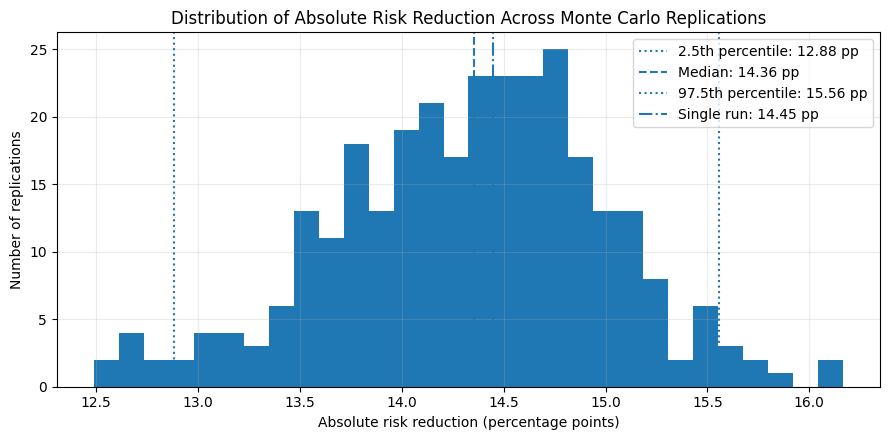

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
arr_pct = rep_results["ARR"] * 100
ax.hist(arr_pct, bins=30)
q025, q50, q975 = arr_pct.quantile([0.025, 0.5, 0.975])
ax.axvline(q025, linestyle=":", label=f"2.5th percentile: {q025:.2f} pp")
ax.axvline(q50, linestyle="--", label=f"Median: {q50:.2f} pp")
ax.axvline(q975, linestyle=":", label=f"97.5th percentile: {q975:.2f} pp")
ax.axvline(arr * 100, linestyle="-.", label=f"Single run: {arr*100:.2f} pp")
ax.set_title("Distribution of Absolute Risk Reduction Across Monte Carlo Replications")
ax.set_xlabel("Absolute risk reduction (percentage points)")
ax.set_ylabel("Number of replications")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Interpretation: Monte Carlo uncertainty

The repeated simulations produce a distribution of absolute risk reduction rather than one fixed value. This demonstrates an important Monte Carlo principle: **random sampling creates simulation variability even when the underlying model assumptions remain unchanged**.

The 2.5th and 97.5th percentiles provide a useful empirical range for the simulation output. They should not be interpreted as a 95% clinical confidence interval.

In [17]:
mc_summary = pd.DataFrame({
    "Metric": ["10-year mortality: No Treatment", "10-year mortality: Treatment", "ARR", "RR", "NNT"],
    "Single run": [risk_no_tx, risk_tx, arr, rr, nnt],
    "2.5th percentile": [rep_results[c].quantile(0.025) for c in ["Mortality_No_Treatment", "Mortality_Treatment", "ARR", "RR", "NNT"]],
    "Median": [rep_results[c].median() for c in ["Mortality_No_Treatment", "Mortality_Treatment", "ARR", "RR", "NNT"]],
    "97.5th percentile": [rep_results[c].quantile(0.975) for c in ["Mortality_No_Treatment", "Mortality_Treatment", "ARR", "RR", "NNT"]],
})
mc_summary

,Metric,Single run,2.5th percentile,Median,97.5th percentile
0,10-year mortality: No Treatment,0.635,0.623,0.632,0.643
1,10-year mortality: Treatment,0.490,0.480,0.489,0.499
2,ARR,0.144,0.129,0.144,0.156
3,RR,0.772,0.755,0.773,0.794
4,NNT,6.922,6.428,6.965,7.764


## 10. Sensitivity analysis: treatment-effect strength

The treatment-effect coefficients are synthetic assumptions. A useful next question is therefore: **How much do the population outcomes change if the assumed treatment effect is weaker or stronger?**

We test three scenarios:
- **Conservative:** 75% of the base treatment effect
- **Base:** 100% of the base treatment effect
- **Optimistic:** 125% of the base treatment effect

This is a scenario analysis, not evidence that these effect sizes correspond to actual clinical treatment effects.

In [18]:
# Use the same 300 random seeds for every scenario so random variation is held constant.
# This isolates the effect of changing the treatment-effect assumption.
sensitivity_scenarios = [("Conservative", 0.75), ("Base", 1.00), ("Optimistic", 1.25)]
sensitivity_rng = np.random.default_rng(RANDOM_SEED + 2)
N_SENS_REPS = 200
sensitivity_seeds = [int(x) for x in sensitivity_rng.integers(0, 2**32 - 1, size=N_SENS_REPS)]

sensitivity_replications = []
for label, multiplier in sensitivity_scenarios:
    for rep, seed in enumerate(sensitivity_seeds, start=1):
        states = simulate_cohort(patients, N_YEARS, seed=seed, treatment_effect_multiplier=multiplier, keep_trajectories=False)
        treatment_mask = patients["Treatment"].to_numpy() == "Treatment"
        no_treatment_mask = ~treatment_mask
        death = states == STATE_IDX["Death"]
        risk_t = death[treatment_mask].mean()
        risk_n = death[no_treatment_mask].mean()
        sensitivity_replications.append({
            "Scenario": label,
            "Treatment effect multiplier": multiplier,
            "Replication": rep,
            "No-treatment mortality": risk_n,
            "Treatment mortality": risk_t,
            "ARR": risk_n - risk_t,
        })

sensitivity_reps = pd.DataFrame(sensitivity_replications)
sensitivity_summary = (
    sensitivity_reps.groupby(["Scenario", "Treatment effect multiplier"], sort=False)
    .agg(
        No_treatment_median=("No-treatment mortality", "median"),
        No_treatment_q025=("No-treatment mortality", lambda x: x.quantile(0.025)),
        No_treatment_q975=("No-treatment mortality", lambda x: x.quantile(0.975)),
        Treatment_median=("Treatment mortality", "median"),
        Treatment_q025=("Treatment mortality", lambda x: x.quantile(0.025)),
        Treatment_q975=("Treatment mortality", lambda x: x.quantile(0.975)),
        ARR_median=("ARR", "median"),
        ARR_q025=("ARR", lambda x: x.quantile(0.025)),
        ARR_q975=("ARR", lambda x: x.quantile(0.975)),
    ).reset_index()
)

sensitivity_display = sensitivity_summary.copy()
for c in ["No_treatment_median", "No_treatment_q025", "No_treatment_q975", "Treatment_median", "Treatment_q025", "Treatment_q975", "ARR_median", "ARR_q025", "ARR_q975"]:
    sensitivity_display[c] = sensitivity_display[c].map(lambda x: f"{x*100:.2f}%")
sensitivity_display


,Scenario,Treatment effect multiplier,No_treatment_median,No_treatment_q025,No_treatment_q975,Treatment_median,Treatment_q025,Treatment_q975,ARR_median,ARR_q025,ARR_q975
0,Conservative,0.750,63.22%,62.36%,64.16%,52.01%,51.02%,52.95%,11.20%,9.87%,12.42%
1,Base,1.000,63.22%,62.36%,64.16%,48.86%,47.99%,49.91%,14.31%,13.07%,15.54%
2,Optimistic,1.250,63.22%,62.36%,64.16%,45.82%,44.99%,46.73%,17.40%,16.22%,18.73%


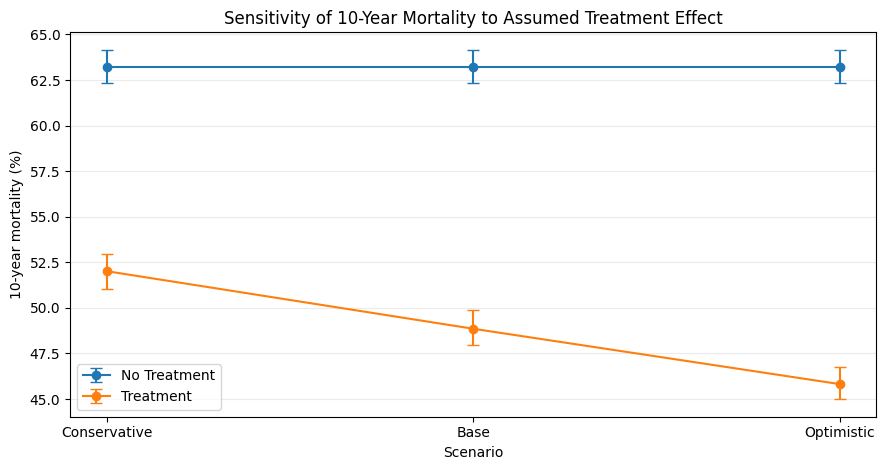

Maximum difference in no-treatment mortality across sensitivity scenario medians: 0.000000000000


In [19]:
x = np.arange(len(sensitivity_summary))
fig, ax = plt.subplots(figsize=(9, 4.8))
for col, label in [("No_treatment_median", "No Treatment"), ("Treatment_median", "Treatment")]:
    med = sensitivity_summary[col].to_numpy() * 100
    q025_col = "No_treatment_q025" if col.startswith("No_") else "Treatment_q025"
    q975_col = "No_treatment_q975" if col.startswith("No_") else "Treatment_q975"
    lower = med - sensitivity_summary[q025_col].to_numpy() * 100
    upper = sensitivity_summary[q975_col].to_numpy() * 100 - med
    ax.errorbar(x, med, yerr=[lower, upper], marker="o", capsize=4, label=label)
ax.set_xticks(x, sensitivity_summary["Scenario"])
ax.set_title("Sensitivity of 10-Year Mortality to Assumed Treatment Effect")
ax.set_xlabel("Scenario")
ax.set_ylabel("10-year mortality (%)")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
print("Maximum difference in no-treatment mortality across sensitivity scenario medians: "
      f"{sensitivity_summary['No_treatment_median'].max() - sensitivity_summary['No_treatment_median'].min():.12f}")


### Interpretation: sensitivity analysis

The sensitivity analysis shows how strongly the simulated treatment comparison depends on the assumed magnitude of the treatment effect. The same random seeds are used across the Conservative, Base, and Optimistic scenarios, so random Monte Carlo variation is held constant while the treatment-effect multiplier changes. The no-treatment mortality therefore remains effectively unchanged, while treatment mortality decreases as the assumed treatment effect becomes stronger.

The error bars show the 2.5th to 97.5th percentile range across 200 paired sensitivity simulations. These are simulation ranges, not clinical confidence intervals. The result reinforces a central modeling lesson: **simulation outcomes are conditional on the assumptions used to generate them**.


## 11. Model validation checks

In [20]:
validation = {
    "All transition probabilities between 0 and 1": bool(((prob_check.iloc[:, :3] >= 0) & (prob_check.iloc[:, :3] <= 1)).all().all()),
    "Transition probabilities sum to 1": bool(np.allclose(prob_check["sum"], 1.0)),
    "Death is absorbing": bool((trajectories.groupby("Patient_ID")["Disease_Stage"].apply(lambda s: (s == "Death").cummax().equals((s == "Death")))).all()),
    "Treatment mortality lower in single run": bool(risk_tx < risk_no_tx),
    "Treatment survival higher in single run": bool(tx["Survival_Rate"] > no_tx["Survival_Rate"]),
    "Baseline annual death probability varies": bool(np.std(p_death_base) > 0),
}
pd.DataFrame({"Check": list(validation.keys()), "Passed": list(validation.values())})


,Check,Passed
0,All transition probabilities between 0 and 1,True
1,Transition probabilities sum to 1,True
2,Death is absorbing,True
3,Treatment mortality lower in single run,True
4,Treatment survival higher in single run,True
5,Baseline annual death probability varies,True


### Interpretation: validation

The checks confirm that the probability system is mathematically valid, Death behaves as an absorbing state, patient-level risk varies across the synthetic cohort, and the base simulation moves in the intended treatment direction. These checks do not validate the model against real clinical outcomes. They validate the **internal logic and implementation of the simulation**.

## 12. Final interpretation and limitations

### Main findings from the simulation

1. The patient-level model introduces heterogeneity that was absent from the earlier fixed-transition approach.
2. The base simulation produces different 10-year mortality and survival outcomes between the treatment scenarios.
3. Repeated Monte Carlo runs show that the estimated treatment difference varies slightly because of random sampling.
4. Sensitivity analysis shows that the size of the simulated treatment benefit depends on the assumed treatment-effect strength, with the comparison isolated using common random seeds across scenarios.

### Limitations

- The dataset is synthetic and does not represent real patients.
- Model coefficients were specified for demonstration rather than estimated from observed outcomes.
- Treatment assignment is synthetic, so the comparison is a scenario analysis rather than causal inference.
- The disease process is simplified into four states: Early, Moderate, Severe, and Death.
- Annual transitions are modeled as discrete yearly events.
- No external clinical validation is performed.
- Simulation intervals describe Monte Carlo variability, not uncertainty about real-world clinical parameters.

### Reproducibility note

The notebook uses a fixed random seed for the main run, controlled independent seeds for repeated simulations, and **common random numbers across sensitivity scenarios** so that treatment-effect changes can be evaluated without confounding them with different random draws. The synthetic input file should be kept alongside the notebook when the project is moved to GitHub.


## 13. Portfolio takeaway

This project demonstrates how **statistics, probability, logistic risk modeling, and Monte Carlo simulation** can be combined to study a health-related decision problem when real patient-level data are unavailable.

The strongest portfolio value is not the synthetic mortality percentage itself. It is the transparent workflow: define assumptions, construct patient-level risk, simulate uncertainty, validate the implementation, inspect visual outputs, and explicitly state what the model can and cannot conclude.